# Custom CNN Baseline for Binary Image Classification

## Overview
This notebook implements a custom CNN architecture with residual blocks and multi-scale feature extraction for binary image classification on an imbalanced dataset. The model uses weighted sampling to handle class imbalance and is evaluated with comprehensive metrics including ROC AUC.

---

## 1. Import Required Libraries

Import all necessary libraries for model building, data loading, training, and evaluation.

In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import numpy as np

## 2. Configuration & Hyperparameters

Set up training configuration including batch size, number of epochs, learning rate, and device (GPU/CPU). 
Verify that the data directory exists.

In [ ]:
# =====================
# 1. CONFIG
# =====================

from pathlib import Path
DATA_DIR = "deep-learning/data"
BATCH_SIZE = 16
EPOCHS = 30  # Increased to 30
LEARNING_RATES = [1e-3, 1e-4, 1e-5]  # List for tuning
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## 3. Define Data Transformations

Create data augmentation pipelines:
- **Train transforms**: Include augmentations (flip, rotation) to improve generalization
- **Val/Test transforms**: Only resize and convert to tensor (no augmentation for consistency)

In [6]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])



val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])


## 4. Load Datasets & Handle Class Imbalance

Load train/val/test datasets from ImageFolder structure. 
Use **WeightedRandomSampler** to handle class imbalance by oversampling the minority class during training.
This ensures the model learns patterns from both classes equally.

In [7]:
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=val_transform)

# Handle imbalance using sampler
labels = [label for _, label in train_dataset.samples]
class_count = np.bincount(labels)
class_weights = 1. / class_count
sample_weights = [class_weights[label] for label in labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

## 5. Define ResidualBlock Architecture

Implement a **Residual Block** with skip connections:
- Two convolution layers with batch normalization and ReLU activation
- Skip connection that adapts dimensions when stride > 1 or input/output channels differ
- Helps prevent vanishing gradients in deep networks

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)

## 6. Define Multi-Scale Block & Custom CNN Model

### MultiScaleBlock
Extracts features at multiple receptive field sizes (1x1, 3x3, 5x5 convolutions) and concatenates them. 
This captures features at different scales, improving feature representation.

### CustomCNN Architecture
- **Stem**: Initial convolution block with max pooling
- **Layer 1-2**: Residual blocks with increasing channels
- **MultiScale**: Multi-scale feature extraction
- **Layer 3**: Final residual block
- **FC Head**: Adaptive pooling + 2 fully connected layers for binary classification (outputs single sigmoid-compatible value)

Instantiate and move model to device.

In [9]:
class MultiScaleBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 1)
        self.conv3 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.conv5 = nn.Conv2d(in_channels, out_channels, 5, padding=2)

    def forward(self, x):
        return torch.cat([
            self.conv1(x),
            self.conv3(x),
            self.conv5(x)
        ], dim=1)

class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 7, stride=2, padding=3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        self.layer1 = ResidualBlock(32, 32)
        self.layer2 = ResidualBlock(32, 64, stride=2)

        self.multi = MultiScaleBlock(64, 32)  # output = 96 channels

        self.layer3 = ResidualBlock(96, 128, stride=2)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.multi(x)
        x = self.layer3(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

model = CustomCNN().to(DEVICE)


## 7. Define Loss Function & Optimizer

- **Loss**: BCEWithLogitsLoss with `pos_weight` to handle class imbalance (weighted loss for minority class)
- **Optimizer**: AdamW with L2 regularization (weight decay)

The pos_weight balances the contribution of positive (minority) class samples in the loss.

## 8. Define Training & Evaluation Functions

### train_epoch()
One training epoch: forward pass, compute loss, backward pass, optimizer step.
Returns average loss and accuracy.

### eval_epoch()
Evaluate on validation/test set without updating model weights.
Returns loss, accuracy, and prediction probabilities for further analysis (e.g., ROC-AUC).

In [11]:
def train_epoch(loader):
    model.train()
    total_loss, correct = 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.float().unsqueeze(1).to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(out) > 0.5).float()
        correct += (preds == y).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)


def eval_epoch(loader):
    model.eval()
    total_loss, correct = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.float().unsqueeze(1).to(DEVICE)
            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item()
            preds = torch.sigmoid(out)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

            binary = (preds > 0.5).float()
            correct += (binary == y).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset), np.array(all_preds), np.array(all_labels)

## 9. Train Model for Multiple Epochs

Run training loop for specified number of epochs:
- Train on training set with augmentation and weighted sampling
- Evaluate on validation set
- Save model checkpoint after each epoch
- Print training progress (loss and accuracy)
- Save final model state

In [12]:


# Create a dictionary to store results for comparison
all_histories = {}

# Create folder for saving models
os.makedirs("tuned_models", exist_ok=True)

for lr in LEARNING_RATES:
    print(f"\n--- Starting Training with LR: {lr} ---")
    
    # Re-initialize model, loss, and optimizer for every LR to start fresh
    model = CustomCNN().to(DEVICE)
    pos_weight = torch.tensor([class_count[0] / class_count[1]]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    
    for epoch in range(EPOCHS):
        # Using your existing train_epoch and eval_epoch functions
        tl, ta = train_epoch(train_loader)
        vl, va, _, _ = eval_epoch(val_loader)

        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_acc"].append(ta)
        history["val_acc"].append(va)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{EPOCHS}: Train Loss {tl:.4f}, Val Loss {vl:.4f}, Val Acc {va:.4f}")

    # Save the final model for this specific LR
    torch.save(model.state_dict(), f"tuned_models/model_lr_{lr}.pth")
    all_histories[lr] = history

print("\n--- Tuning Complete ---")


--- Starting Training with LR: 0.001 ---
Epoch 1/30: Train Loss 1.9901, Val Loss 2.3571, Val Acc 0.0500
Epoch 5/30: Train Loss 1.8599, Val Loss 2.6655, Val Acc 0.0500
Epoch 10/30: Train Loss 1.7111, Val Loss 2.0711, Val Acc 0.0860
Epoch 15/30: Train Loss 1.4059, Val Loss 1.8133, Val Acc 0.3830
Epoch 20/30: Train Loss 1.1878, Val Loss 1.6863, Val Acc 0.4520
Epoch 25/30: Train Loss 0.9607, Val Loss 1.4588, Val Acc 0.6560
Epoch 30/30: Train Loss 0.8552, Val Loss 1.6147, Val Acc 0.6790

--- Starting Training with LR: 0.0001 ---
Epoch 1/30: Train Loss 2.0314, Val Loss 2.9585, Val Acc 0.0500
Epoch 5/30: Train Loss 1.6970, Val Loss 3.4282, Val Acc 0.0610
Epoch 10/30: Train Loss 1.3743, Val Loss 2.1862, Val Acc 0.2300
Epoch 15/30: Train Loss 1.1487, Val Loss 1.7142, Val Acc 0.4360
Epoch 20/30: Train Loss 0.9824, Val Loss 2.1907, Val Acc 0.3540
Epoch 25/30: Train Loss 0.8844, Val Loss 1.6456, Val Acc 0.5800
Epoch 30/30: Train Loss 0.7321, Val Loss 1.4825, Val Acc 0.7540

--- Starting Training 

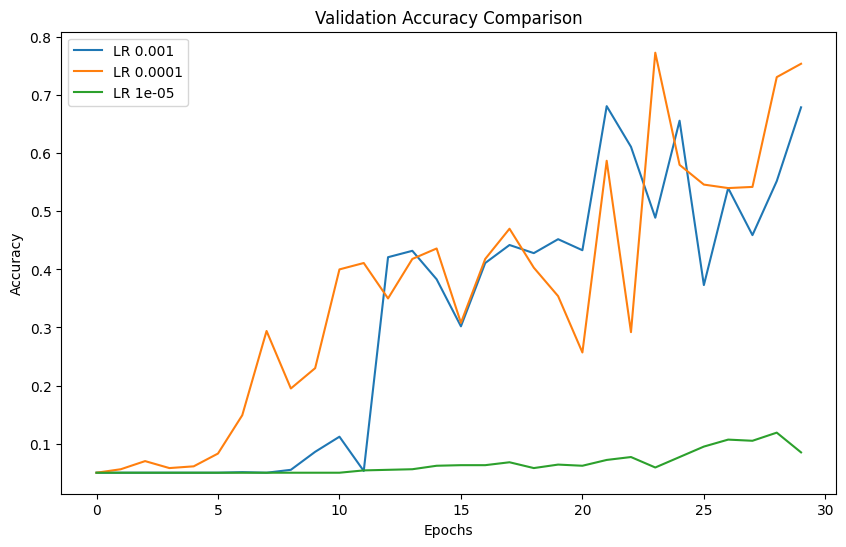

In [13]:
plt.figure(figsize=(10, 6))
for lr, hist in all_histories.items():
    plt.plot(hist['val_acc'], label=f'LR {lr}')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [14]:
import os
import torch
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score, accuracy_score

# Define the path where your models are saved
model_dir = "tuned_models"  # Or "cusmodel" depending on your previous run
test_results = []

# List of learning rates you used for tuning
learning_rates = [1e-3, 1e-4, 1e-5] 

for lr in learning_rates:
    # 1. Initialize a fresh model architecture
    model = CustomCNN().to(DEVICE)
    
    # 2. Load the saved weights for this specific LR
    model_path = f"{model_dir}/model_lr_{lr}.pth"
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path))
        print(f"Testing model with LR: {lr}...")

        # 3. Run evaluation on the test set
        # We ignore the accuracy returned by eval_epoch to calculate it uniformly below
        test_loss, _, test_preds, test_labels = eval_epoch(test_loader)
        
        # Ensure predictions and labels are numpy arrays for sklearn
        test_preds = np.array(test_preds)
        test_labels = np.array(test_labels)

        # Convert raw probabilities to binary predictions using a 0.5 threshold
        binary_preds = (test_preds >= 0.5).astype(int)
        
        # 4. Calculate final metrics requested for the table
        auroc = roc_auc_score(test_labels, test_preds)
        f1 = f1_score(test_labels, binary_preds)
        avg_precision = average_precision_score(test_labels, test_preds)
        overall_accuracy = accuracy_score(test_labels, binary_preds)
        
        # Append to results using the exact column names you need
        test_results.append({
            "Metric": f"LR_{lr}", # Added to identify the row, optional
            "AUROC": auroc,
            "F1-Score": f1,
            "Average Precision": avg_precision,
            "Overall Accuracy": overall_accuracy
        })
        
        print(f"Results for LR {lr}: AUROC={auroc:.4f}, F1={f1:.4f}, AP={avg_precision:.4f}, Acc={overall_accuracy:.4f}")
    else:
        print(f"Checkpoint not found for LR: {lr}")

# Display results in a table for easy comparison
results_df = pd.DataFrame(test_results)
print("\n--- Final Test Set Comparison ---")
print(results_df.to_string(index=False)) # to_string(index=False) hides the default pandas row numbers

Testing model with LR: 0.001...
Results for LR 0.001: AUROC=0.8353, F1=0.2010, AP=0.3318, Acc=0.6660
Testing model with LR: 0.0001...
Results for LR 0.0001: AUROC=0.8812, F1=0.2569, AP=0.3877, Acc=0.7570
Testing model with LR: 1e-05...
Results for LR 1e-05: AUROC=0.7454, F1=0.0998, AP=0.1904, Acc=0.0980

--- Final Test Set Comparison ---
   Metric    AUROC  F1-Score  Average Precision  Overall Accuracy
 LR_0.001 0.835326  0.200957           0.331795             0.666
LR_0.0001 0.881221  0.256881           0.387698             0.757
 LR_1e-05 0.745389  0.099800           0.190414             0.098
